### DSC 640 - Milestone 1 Preliminary Analysis
#### Nana Noda-Morgan

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

data = pd.read_excel("nationaldatabaseofchildcareprices.xlsx", sheet_name="nationaldatabaseofchildcare")

In [34]:
print("# of Columns:", len(df.columns))
print("\nFirst 10 rows:")
display(df.head(10))

print("\nColumn datatypes:")
print(df.dtypes.sort_index())

print("\nCount missing values-top 25:")
na = df.isna().mean().sort_values(ascending=False)
display(na.head(25))

# of Columns: 227

First 10 rows:


,State_Name,State_Abbreviation,County_Name,County_FIPS_Code,StudyYear,UNR_16,FUNR_16,MUNR_16,UNR_20to64,FUNR_20to64,...,MFCCToddler,MFCCToddler_flag,MFCCPreschool,MFCCPreschool_flag,_75FCCInfant,_75FCCInfant_flag,_75FCCToddler,_75FCCToddler_flag,_75FCCPreschool,_75FCCPreschool_flag
0,Alabama,AL,Autauga County,01001,2008,5.42,4.41,6.32,4.6,3.5,...,83.45,3.0,81.40,1.0,97.4,1.0,97.4,3.0,95.00,1.0
1,Alabama,AL,Autauga County,01001,2009,5.93,5.72,6.11,4.8,4.6,...,87.39,3.0,85.68,1.0,102.0,1.0,102.0,3.0,100.00,1.0
2,Alabama,AL,Autauga County,01001,2010,6.21,5.57,6.78,5.1,4.6,...,91.33,3.0,89.96,1.0,106.6,1.0,106.6,3.0,105.00,1.0
3,Alabama,AL,Autauga County,01001,2011,7.55,8.13,7.03,6.2,6.3,...,95.28,3.0,94.25,1.0,111.2,1.0,111.2,3.0,110.00,1.0
4,Alabama,AL,Autauga County,01001,2012,8.60,8.88,8.29,6.7,6.4,...,99.22,3.0,98.53,1.0,115.8,1.0,115.8,3.0,115.00,1.0
5,Alabama,AL,Autauga County,01001,2013,9.39,10.31,8.56,7.3,7.6,...,103.16,3.0,102.82,1.0,120.4,1.0,120.4,3.0,120.00,1.0
6,Alabama,AL,Autauga County,01001,2014,8.50,9.18,7.95,6.8,6.8,...,107.10,1.0,107.10,1.0,125.0,1.0,125.0,1.0,125.00,1.0
7,Alabama,AL,Autauga County,01001,2015,7.64,8.45,6.91,5.9,6.1,...,107.10,3.0,106.81,1.0,125.0,1.0,125.0,3.0,124.67,1.0
8,Alabama,AL,Autauga County,01001,2016,5.59,6.27,4.99,4.4,4.6,...,107.10,3.0,106.53,1.0,125.0,1.0,125.0,3.0,124.33,1.0
9,Alabama,AL,Autauga County,01001,2017,5.21,5.84,4.64,4.6,4.9,...,107.10,3.0,106.24,1.0,125.0,1.0,125.0,3.0,124.00,1.0



Column datatypes:
County_FIPS_Code     object
County_Name          object
EMP_M               float64
EMP_N               float64
EMP_P               float64
                     ...   
i_75FCC48to53       float64
i_75FCC54toSA       float64
i_75FCC6to11        float64
i_75FCCBto5         float64
i_75FCCSA           float64
Length: 227, dtype: object

Count missing values-top 25:


iMFCC12to17     0.324124
iMFCCBto5       0.324124
iMFCC54toSA     0.324124
iMFCC48to53     0.324124
iMFCC42to47     0.324124
iMFCC36to41     0.324124
iMFCC30to35     0.324124
iMFCC24to29     0.324124
iMFCC18to23     0.324124
iMFCC6to11      0.324124
iMFCCSA         0.324124
MFCC54toSA      0.323546
_75FCCSA        0.323546
MFCCBto5        0.323546
MFCC6to11       0.323546
MFCC12to17      0.323546
MFCC18to23      0.323546
MFCC24to29      0.323546
MFCC30to35      0.323546
MFCC36to41      0.323546
MFCC42to47      0.323546
MFCC48to53      0.323546
_75FCC54toSA    0.323546
MFCCSA          0.323546
_75FCC48to53    0.323546
dtype: float64


Rows by StudyYear:


StudyYear
2008    3142
2009    3143
2010    3143
2011    3143
2012    3143
2013    3143
2014    3142
2015    3142
2016    3142
2017    3142
2018    3142
Name: count, dtype: int64

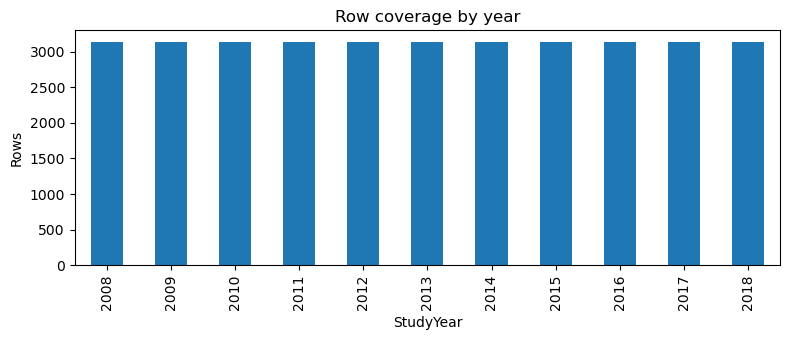

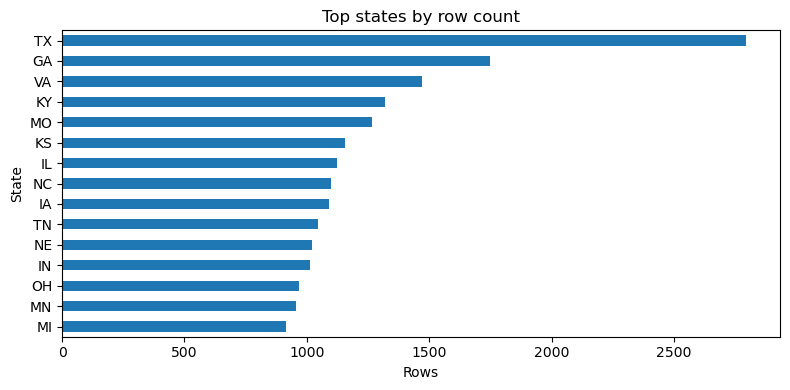

In [29]:
if "StudyYear" in df.columns:
    yr_counts = df["StudyYear"].value_counts().sort_index()
    print("\nRows by StudyYear:")
    display(yr_counts)

    # Quick plot
    plt.figure(figsize=(8,3.5))
    yr_counts.plot(kind="bar")
    plt.title("Row coverage by year")
    plt.xlabel("StudyYear"); plt.ylabel("Rows")
    plt.tight_layout(); plt.show()

# Rows by state (top 15)
if "State_Abbreviation" in df.columns:
    st_counts = df["State_Abbreviation"].value_counts().head(15)
    plt.figure(figsize=(8,4))
    st_counts.sort_values().plot(kind="barh")
    plt.title("Top states by row count")
    plt.xlabel("Rows"); plt.ylabel("State")
    plt.tight_layout(); plt.show()

In [17]:
#focus on childcare prices and income
cols_all = data.columns.tolist()

#narrow downt to price to MFCC or MFCC for Infant, Toddler, and Preschool since I think the months are too granular
id_cols = [c for c in ["County_FIPS_Code","County_Name","State_Abbreviation","StudyYear"] if c in cols_all]
price_candidates  = [c for c in ["MFCCInfant","MCCCInfant","MFCCToddler","MCCCToddler","MFCCPreschool","MCCCPreschool"] if c in cols_all]
income_candidates = [c for c in ["MHI","iMHI","MHI_2018","iMHI_2018"] if c in cols_all]

print("ID cols:", id_cols)
print("Price candidates:", price_candidates)
print("Income candidates:", income_candidates)

ID cols: ['County_FIPS_Code', 'County_Name', 'State_Abbreviation', 'StudyYear']
Price candidates: ['MFCCInfant', 'MFCCToddler', 'MFCCPreschool']
Income candidates: ['MHI', 'iMHI', 'MHI_2018', 'iMHI_2018']


In [23]:
#Load only the needed columns for less cleaning
use_cols = list(dict.fromkeys(id_cols + price_candidates + income_candidates))  # dedupe, keep order
df_raw = pd.read_excel("nationaldatabaseofchildcareprices.xlsx", sheet_name="nationaldatabaseofchildcare", usecols=use_cols)

#set FIPS as zero-padded string, StudyYear as int
if "County_FIPS_Code" in df_raw.columns:
    df_raw["County_FIPS_Code"] = (df_raw["County_FIPS_Code"]
                                  .astype(str)
                                  .str.replace(r"\.0$", "", regex=True)
                                  .str.zfill(5))

if "StudyYear" in df_raw.columns:
    df_raw["StudyYear"] = pd.to_numeric(df_raw["StudyYear"], errors="coerce").astype("Int64")

# Drop duplicate county-year rows if any
if set(["County_FIPS_Code","StudyYear"]).issubset(df_raw.columns):
    before = len(df_raw)
    df_raw = df_raw.drop_duplicates(subset=["County_FIPS_Code","StudyYear"])
    print("Dropped duplicate county-year rows:", before - len(df_raw))

df_raw.head(3)

Dropped duplicate county-year rows: 0


,State_Abbreviation,County_Name,County_FIPS_Code,StudyYear,MHI,MHI_2018,iMHI,iMHI_2018,MFCCInfant,MFCCToddler,MFCCPreschool
0,AL,Autauga County,01001,2008,50837.0,58462.55,0,1,83.45,83.45,81.40
1,AL,Autauga County,01001,2009,51463.0,60211.71,0,1,87.39,87.39,85.68
2,AL,Autauga County,01001,2010,53255.0,61775.80,0,1,91.33,91.33,89.96


In [25]:
#Pick a primary price column and a clean snapshot year

cov_by_col = {}
for c in price_candidates:
    cov_by_col[c] = df_raw.groupby("StudyYear")[c].apply(lambda s: s.notna().mean()).mean()


primary_price_col = max(cov_by_col, key=cov_by_col.get)
print("Primary price:", primary_price_col, "| mean coverage:", round(cov_by_col[primary_price_col], 3))

#Choose the latest year with reasonable coverage (≥60%) for that column
per_year_cov = df_raw.groupby("StudyYear")[primary_price_col].apply(lambda s: s.notna().mean()).sort_index()
candidate_years = per_year_cov[per_year_cov >= 0.60].index.tolist()
snapshot_year = int(candidate_years[-1]) if candidate_years else int(per_year_cov.dropna().index[-1])
print("Chosen snapshot year:", snapshot_year)

Primary price: MFCCInfant | mean coverage: 0.676
Chosen snapshot year: 2018


In [15]:
#Attach a single income column as income and build a snapshot
if "MHI" in income_candidates:
    income_col = "MHI"
elif "iMHI" in income_candidates:
    income_col = "iMHI"
elif "MHI_2018" in income_candidates:
    income_col = "MHI_2018"
else:
    income_col = "iMHI_2018"

#Start with id + primary price
df = df_raw[id_cols + [primary_price_col]].copy()

#Merge income
df = df.drop(columns=[c for c in df.columns if c.lower()=="income"], errors="ignore")
if income_col.endswith("_2018"):
    attach = (df_raw[["County_FIPS_Code", income_col]]
              .drop_duplicates()
              .rename(columns={income_col: "income"}))
    df = df.merge(attach, on="County_FIPS_Code", how="left")
else:
    attach = (df_raw[["County_FIPS_Code","StudyYear", income_col]]
              .drop_duplicates()
              .rename(columns={income_col: "income"}))
    df = df.merge(attach, on=["County_FIPS_Code","StudyYear"], how="left")

#Keep the snapshot year, drop impossible/empty values
base = (df[df["StudyYear"] == snapshot_year]
        .dropna(subset=[primary_price_col, "income"])
        .copy())

#prices are weekly so annualize
base["annual_price"] = base[primary_price_col] * 52
base["burden"] = base["annual_price"] / base["income"]

#just in case drop nonpositive or clearly invalid
base = base[(base["annual_price"] > 0) & (base["income"] > 0)]

print(f"Snapshot {snapshot_year}: rows (counties) = {len(base):,}")
print("Columns available:", list(base.columns))

Snapshot 2018: rows (counties) = 2,348
Columns available: ['County_FIPS_Code', 'County_Name', 'State_Abbreviation', 'StudyYear', 'MFCCInfant', 'income', 'annual_price', 'burden']


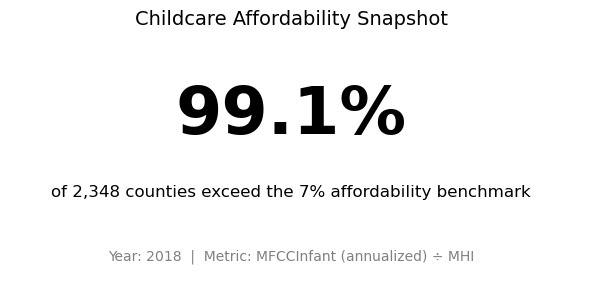

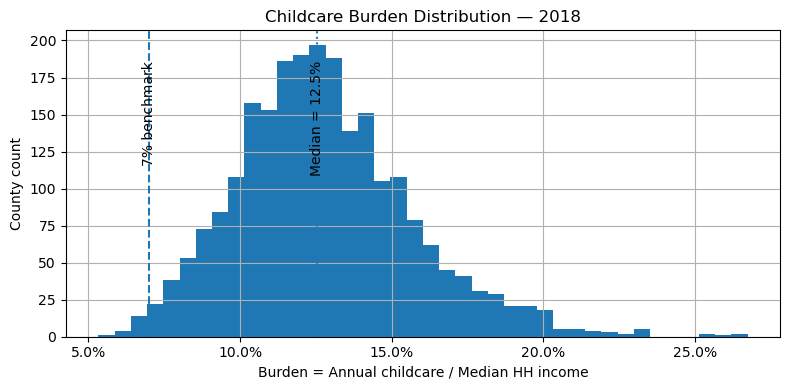

In [23]:
##test some visualizations
import matplotlib.ticker as mtick

AFFORD = 0.07 #7% affordability benchmark (via online research)
share_above = (base["burden"] > AFFORD).mean()
median_burden = base["burden"].median()
n_counties = len(base)

#plot a single number tile
fig = plt.figure(figsize=(7.5,3.2))
fig.suptitle("Childcare Affordability Snapshot", y=0.95, fontsize=14)
fig.text(0.5, 0.62, f"{share_above*100:.1f}%", ha="center", va="center",
         fontsize=48, fontweight="bold")
fig.text(0.5, 0.38, f"of {n_counties:,} counties exceed the 7% affordability benchmark",
         ha="center", va="center", fontsize=12)
fig.text(0.5, 0.18, f"Year: {snapshot_year}  |  Metric: {primary_price_col} (annualized) ÷ {income_col}",
         ha="center", va="center", fontsize=10, color="gray")
plt.axis("off")
plt.show()

#plot the histogram with benchmark and median
plt.figure(figsize=(8,4))
plt.hist(base["burden"], bins=40)
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
plt.axvline(AFFORD, linestyle="--")
plt.axvline(median_burden, linestyle=":")
plt.title(f"Childcare Burden Distribution — {snapshot_year}")
plt.xlabel("Burden = Annual childcare / Median HH income")
plt.ylabel("County count")
plt.text(AFFORD, plt.ylim()[1]*0.9, "7% benchmark", rotation=90, va="top", ha="center")
plt.text(median_burden, plt.ylim()[1]*0.9, f"Median = {median_burden*100:.1f}%", rotation=90, va="top", ha="center")
plt.tight_layout()
plt.show()

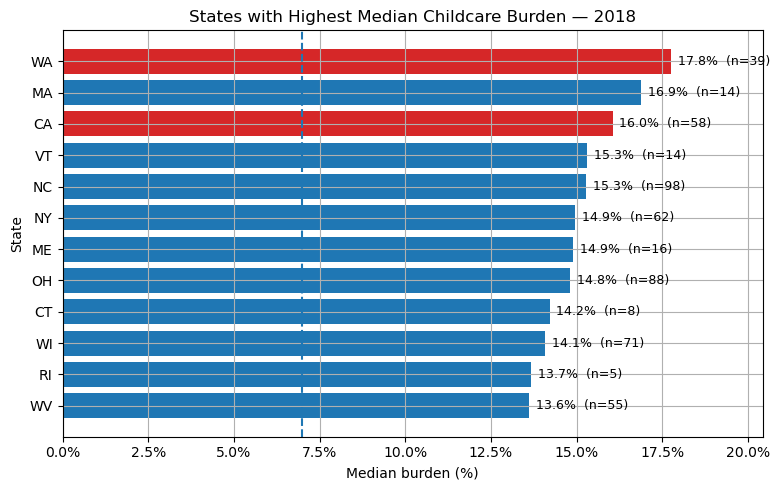

In [33]:
##States with Highest Median Childcare Burden 

MIN_COUNTIES = 5
N_TOP = 12
HIGHLIGHT_STATE = ("CA","WA")

#calculate state medians
state_burden = (base.groupby("State_Abbreviation", as_index=False)
                .agg(median_burden=("burden","median"),
                     n_counties=("burden","size")))
state_burden = state_burden[state_burden["n_counties"] >= MIN_COUNTIES]

top_states = (state_burden.sort_values("median_burden", ascending=False)
                          .head(N_TOP)
                          .sort_values("median_burden"))

vals = top_states["median_burden"].values * 100.0
states = top_states["State_Abbreviation"].values
ns = top_states["n_counties"].values

#highlight WA & CA
colors = ["#d62728" if s in HIGHLIGHT_STATE else "#1f77b4" for s in states]

plt.figure(figsize=(8,5))
ax = plt.barh(range(len(states)), vals, color=colors)
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter())

#add extra headroom for visualization
xmax = max(vals) * 1.15
plt.xlim(0, xmax)

#7% benchmark line
plt.axvline(AFFORD*100, linestyle="--")

plt.yticks(range(len(states)), states)
plt.ylabel("State")
plt.title(f"States with Highest Median Childcare Burden — {snapshot_year}")
plt.xlabel("Median burden (%)")

# Value labels placed safely inside axes
for i, (v, n, s) in enumerate(zip(vals, ns, states)):
    x_pos = min(v + 0.2, xmax - 1.0)      # keep inside right edge
    label = f"{v:.1f}%  (n={n})"
    ha = "left"
    plt.text(x_pos, i, label, va="center", ha=ha, fontsize=9)

plt.tight_layout()
plt.show()

In [8]:
synth_data = pd.read_csv("employer_sites_hr_synthetic_showcase.csv")

print("\nFirst 10 rows:")
display(synth_data.head(10))


First 10 rows:


,Employer,SiteName,County_Name,State_Abbreviation,County_FIPS_Code,Headcount,Percent_Parents_U6,Avg_Salary,Remote_Share,Baseline_Turnover_Rate,Cost_Per_Turnover,Retention_Lift_If_Stipend,Uptake_Rate,Avg_Children_Per_Parent,Sector
0,Apple,Cupertino HQ,Santa Clara County,CA,6085,23000,0.16,210000,0.23,0.17,252000,0.15,0.72,1.10,Tech
1,Google,Mountain View,Santa Clara County,CA,6085,22000,0.17,220000,0.28,0.18,264000,0.15,0.72,1.10,Tech
2,NVIDIA,Santa Clara,Santa Clara County,CA,6085,9000,0.18,205000,0.33,0.16,246000,0.15,0.72,1.10,Tech
3,HP,Palo Alto,Santa Clara County,CA,6085,6000,0.15,165000,0.38,0.19,198000,0.15,0.72,1.10,Tech
4,Meta,Menlo Park,San Mateo County,CA,6081,15000,0.17,215000,0.38,0.18,258000,0.15,0.72,1.10,Tech
5,Salesforce,San Francisco,San Francisco County,CA,6075,12000,0.16,200000,0.43,0.17,240000,0.15,0.72,1.10,Tech
6,Uber,San Francisco HQ,San Francisco County,CA,6075,7000,0.15,190000,0.43,0.20,228000,0.15,0.72,1.10,Tech
7,Disney,Burbank,Los Angeles County,CA,6037,18000,0.17,140000,0.18,0.22,168000,0.15,0.72,1.25,Media
8,Qualcomm,San Diego,San Diego County,CA,6073,11000,0.17,175000,0.28,0.18,210000,0.15,0.72,1.10,Tech
9,Oracle,Redwood Shores,San Mateo County,CA,6081,8000,0.16,180000,0.43,0.19,216000,0.15,0.72,1.10,Tech


In [10]:
#more exploration on this new dataset
print("Rows:", len(synth_data), " | Columns:", len(synth_data.columns))
print("\nColumn datatypes:")
print(synth_data.dtypes.sort_index())

print("\nMissing values per column):")
display(synth_data.isna().mean().sort_values(ascending=False).to_frame("share_missing").head(20))

Rows: 22  | Columns: 15

Column datatypes:
Avg_Children_Per_Parent      float64
Avg_Salary                     int64
Baseline_Turnover_Rate       float64
Cost_Per_Turnover              int64
County_FIPS_Code               int64
County_Name                   object
Employer                      object
Headcount                      int64
Percent_Parents_U6           float64
Remote_Share                 float64
Retention_Lift_If_Stipend    float64
Sector                        object
SiteName                      object
State_Abbreviation            object
Uptake_Rate                  float64
dtype: object

Missing values per column):


,share_missing
Employer,0.0
SiteName,0.0
County_Name,0.0
State_Abbreviation,0.0
County_FIPS_Code,0.0
Headcount,0.0
Percent_Parents_U6,0.0
Avg_Salary,0.0
Remote_Share,0.0
Baseline_Turnover_Rate,0.0


In [14]:
main_num = [
    "Headcount","Percent_Parents_U6","Avg_Salary","Remote_Share",
    "Baseline_Turnover_Rate","Cost_Per_Turnover",
    "Retention_Lift_If_Stipend","Uptake_Rate","Avg_Children_Per_Parent"
]
present_main = [c for c in main_num if c in synth_data.columns]

desc = synth_data[present_main].describe(percentiles=[0.1,0.25,0.5,0.75,0.9]).T
display(desc.style.format({
    "Headcount":"{:,.0f}",
    "Avg_Salary":"${:,.0f}",
    "Cost_Per_Turnover":"${:,.0f}",
    "Percent_Parents_U6":"{:.1%}",
    "Remote_Share":"{:.1%}",
    "Baseline_Turnover_Rate":"{:.1%}",
    "Retention_Lift_If_Stipend":"{:.1%}",
    "Uptake_Rate":"{:.1%}",
    "Avg_Children_Per_Parent":"{:.2f}",
}))

,count,mean,std,min,10%,25%,50%,75%,90%,max
Headcount,22.000000,13681.818182,8149.708517,3000.000000,5100.000000,8000.000000,12000.000000,17500.000000,22900.000000,35000.000000
Percent_Parents_U6,22.000000,0.170455,0.013965,0.150000,0.151000,0.160000,0.170000,0.180000,0.190000,0.200000
Avg_Salary,22.000000,154772.727273,42467.838608,90000.000000,105500.000000,116250.000000,152500.000000,188750.000000,209500.000000,220000.000000
Remote_Share,22.000000,0.229091,0.137075,0.050000,0.050000,0.092500,0.255000,0.330000,0.425000,0.430000
Baseline_Turnover_Rate,22.000000,0.196818,0.034280,0.160000,0.170000,0.180000,0.190000,0.200000,0.220000,0.300000
Cost_Per_Turnover,22.000000,185727.272727,50961.406329,108000.000000,126600.000000,139500.000000,183000.000000,226500.000000,251400.000000,264000.000000
Retention_Lift_If_Stipend,22.000000,0.150000,0.000000,0.150000,0.150000,0.150000,0.150000,0.150000,0.150000,0.150000
Uptake_Rate,22.000000,0.720000,0.000000,0.720000,0.720000,0.720000,0.720000,0.720000,0.720000,0.720000
Avg_Children_Per_Parent,22.000000,1.168182,0.077989,1.100000,1.100000,1.100000,1.100000,1.250000,1.250000,1.300000
